<a href="https://colab.research.google.com/github/tanvir-mahadi2516/ML_Driven_Air_Quality_Prediction/blob/main/AQPMS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost imbalanced-learn

In [ ]:
!ls /content/drive/MyDrive/ML_Project/

ls: cannot access '/content/drive/MyDrive/ML_Project/': No such file or directory


In [ ]:
!ls /content/


Dhaka_PM2.5_2016.csv  Dhaka_PM2.5_2019.csv  Dhaka_PM2.5_2022.csv
Dhaka_PM2.5_2017.csv  Dhaka_PM2.5_2020.csv  sample_data
Dhaka_PM2.5_2018.csv  Dhaka_PM2.5_2021.csv


In [ ]:
import pandas as pd
import glob

# Load all CSV files from /content/
files = glob.glob('/content/Dhaka_PM2.5_*.csv')
dfs = [pd.read_csv(file) for file in files]
data = pd.concat(dfs, ignore_index=True)

# Check data
print(data.head())
print(data.columns)
print(data.shape)

          Date (LT)  Hour  NowCast Conc.  Raw Conc. Conc. Unit  AQI  \
0  01/01/2018 01:00     1          164.4        164      ug/m3  215   
1  01/01/2018 02:00     2          180.2        196      ug/m3  230   
2  01/01/2018 03:00     3          172.6        165      ug/m3  223   
3  01/01/2018 04:00     4          156.8        141      ug/m3  207   
4  01/01/2018 05:00     5          152.9        147      ug/m3  203   

     AQI Category QC Name  
0  Very Unhealthy   Valid  
1  Very Unhealthy   Valid  
2  Very Unhealthy   Valid  
3  Very Unhealthy   Valid  
4  Very Unhealthy   Valid  
Index(['Date (LT)', 'Hour', 'NowCast Conc.', 'Raw Conc.', 'Conc. Unit', 'AQI',
       'AQI Category', 'QC Name'],
      dtype='object')
(53355, 8)


In [ ]:
for file in files:
    df = pd.read_csv(file)
    print(f"Columns in {file}:", df.columns.tolist())

Columns in /content/Dhaka_PM2.5_2018.csv: ['Date (LT)', 'Hour', 'NowCast Conc.', 'Raw Conc.', 'Conc. Unit', 'AQI', 'AQI Category', 'QC Name']
Columns in /content/Dhaka_PM2.5_2021.csv: ['Date (LT)', 'Hour', 'NowCast Conc.', 'Raw Conc.', 'Conc. Unit', 'AQI', 'AQI Category', 'QC Name']
Columns in /content/Dhaka_PM2.5_2019.csv: ['Date (LT)', 'Hour', 'NowCast Conc.', 'Raw Conc.', 'Conc. Unit', 'AQI', 'AQI Category', 'QC Name']
Columns in /content/Dhaka_PM2.5_2017.csv: ['Date (LT)', 'Hour', 'NowCast Conc.', 'Raw Conc.', 'Conc. Unit', 'AQI', 'AQI Category', 'QC Name']
Columns in /content/Dhaka_PM2.5_2016.csv: ['Date (LT)', 'Hour', 'NowCast Conc.', 'Raw Conc.', 'Conc. Unit', 'AQI', 'AQI Category', 'QC Name']
Columns in /content/Dhaka_PM2.5_2022.csv: ['Date (LT)', 'Hour', 'NowCast Conc.', 'Raw Conc.', 'Conc. Unit', 'AQI', 'AQI Category', 'QC Name']
Columns in /content/Dhaka_PM2.5_2020.csv: ['Date (LT)', 'Hour', 'NowCast Conc.', 'Raw Conc.', 'Conc. Unit', 'AQI', 'AQI Category', 'QC Name']


In [ ]:
print(data.isnull().sum())
data['NowCast Conc.'].fillna(data['NowCast Conc.'].mean(), inplace=True)
data['Raw Conc.'].fillna(data['Raw Conc.'].mean(), inplace=True)
data['AQI'].fillna(data['AQI'].mean(), inplace=True)
data.dropna(subset=['AQI Category'], inplace=True)
data = data[data['QC Name'] == 'Valid']

Date (LT)           0
Hour                0
NowCast Conc.       0
Raw Conc.           0
Conc. Unit          0
AQI                 0
AQI Category     1858
QC Name             0
dtype: int64


/tmp/ipython-input-12-1187218811.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['NowCast Conc.'].fillna(data['NowCast Conc.'].mean(), inplace=True)
/tmp/ipython-input-12-1187218811.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['AQI_Category_Encoded'] = le.fit_transform(data['AQI Category'])
print("Encoded classes:", le.classes_)

Encoded classes: ['Good' 'Hazardous' 'Moderate' 'Unhealthy'
 'Unhealthy for Sensitive Groups' 'Very Unhealthy']


In [ ]:
data['Date (LT)'] = pd.to_datetime(data['Date (LT)'], errors='coerce')
data['Month'] = data['Date (LT)'].dt.month
data['DayOfWeek'] = data['Date (LT)'].dt.dayofweek
features = ['NowCast Conc.', 'Raw Conc.', 'Hour', 'Month', 'DayOfWeek']
X = data[features]
y = data['AQI_Category_Encoded']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Splitting dataset

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
print(f"Train: {len(X_train)} samples ({len(X_train)/len(X):.2%})")
print(f"Validation: {len(X_val)} samples ({len(X_val)/len(X):.2%})")
print(f"Test: {len(X_test)} samples ({len(X_test)/len(X):.2%})")

Train: 35686 samples (70.00%)
Validation: 7647 samples (15.00%)
Test: 7648 samples (15.00%)


Handle Class Imbalance

In [ ]:
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd

print("Class distribution:", pd.Series(y).value_counts(normalize=True))

# Check for NaN values in X and y
if np.any(np.isnan(X)) or np.any(np.isnan(y)):
    print("NaN values found in X or y. Please handle them before applying SMOTE.")
else:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print("After SMOTE, Train class distribution:", pd.Series(y_train).value_counts(normalize=True))

Class distribution: AQI_Category_Encoded
3    0.368789
2    0.248683
4    0.193874
5    0.133452
1    0.030728
0    0.024474
Name: proportion, dtype: float64
After SMOTE, Train class distribution: AQI_Category_Encoded
4    0.166667
2    0.166667
3    0.166667
5    0.166667
0    0.166667
1    0.166667
Name: proportion, dtype: float64


start again


In [ ]:
import pandas as pd
import glob
import numpy as np

files = glob.glob('/content/Dhaka_PM2.5_*.csv')
dfs = [pd.read_csv(file) for file in files]
data = pd.concat(dfs, ignore_index=True)
print(data.head())
print(data.columns)
print(data.shape)

          Date (LT)  Hour  NowCast Conc.  Raw Conc. Conc. Unit  AQI  \
0  01/01/2018 01:00     1          164.4        164      ug/m3  215   
1  01/01/2018 02:00     2          180.2        196      ug/m3  230   
2  01/01/2018 03:00     3          172.6        165      ug/m3  223   
3  01/01/2018 04:00     4          156.8        141      ug/m3  207   
4  01/01/2018 05:00     5          152.9        147      ug/m3  203   

     AQI Category QC Name  
0  Very Unhealthy   Valid  
1  Very Unhealthy   Valid  
2  Very Unhealthy   Valid  
3  Very Unhealthy   Valid  
4  Very Unhealthy   Valid  
Index(['Date (LT)', 'Hour', 'NowCast Conc.', 'Raw Conc.', 'Conc. Unit', 'AQI',
       'AQI Category', 'QC Name'],
      dtype='object')
(53355, 8)


In [ ]:
for file in files:
    df = pd.read_csv(file)
    print(f"Columns in {file}:", df.columns.tolist())

Columns in /content/Dhaka_PM2.5_2018.csv: ['Date (LT)', 'Hour', 'NowCast Conc.', 'Raw Conc.', 'Conc. Unit', 'AQI', 'AQI Category', 'QC Name']
Columns in /content/Dhaka_PM2.5_2021.csv: ['Date (LT)', 'Hour', 'NowCast Conc.', 'Raw Conc.', 'Conc. Unit', 'AQI', 'AQI Category', 'QC Name']
Columns in /content/Dhaka_PM2.5_2019.csv: ['Date (LT)', 'Hour', 'NowCast Conc.', 'Raw Conc.', 'Conc. Unit', 'AQI', 'AQI Category', 'QC Name']
Columns in /content/Dhaka_PM2.5_2017.csv: ['Date (LT)', 'Hour', 'NowCast Conc.', 'Raw Conc.', 'Conc. Unit', 'AQI', 'AQI Category', 'QC Name']
Columns in /content/Dhaka_PM2.5_2016.csv: ['Date (LT)', 'Hour', 'NowCast Conc.', 'Raw Conc.', 'Conc. Unit', 'AQI', 'AQI Category', 'QC Name']
Columns in /content/Dhaka_PM2.5_2022.csv: ['Date (LT)', 'Hour', 'NowCast Conc.', 'Raw Conc.', 'Conc. Unit', 'AQI', 'AQI Category', 'QC Name']
Columns in /content/Dhaka_PM2.5_2020.csv: ['Date (LT)', 'Hour', 'NowCast Conc.', 'Raw Conc.', 'Conc. Unit', 'AQI', 'AQI Category', 'QC Name']


In [ ]:
print(data.isnull().sum())
data['NowCast Conc.'].fillna(data['NowCast Conc.'].mean(), inplace=True)
data['Raw Conc.'].fillna(data['Raw Conc.'].mean(), inplace=True)
data['AQI'].fillna(data['AQI'].mean(), inplace=True)
data.dropna(subset=['AQI Category', 'QC Name'], inplace=True)
data = data[data['QC Name'] == 'Valid']

Date (LT)           0
Hour                0
NowCast Conc.       0
Raw Conc.           0
Conc. Unit          0
AQI                 0
AQI Category     1858
QC Name             0
dtype: int64


/tmp/ipython-input-3-834771219.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['NowCast Conc.'].fillna(data['NowCast Conc.'].mean(), inplace=True)
/tmp/ipython-input-3-834771219.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

In [ ]:
print(X.isna().sum())

NowCast Conc.    0
Raw Conc.        0
Hour             0
Month            0
DayOfWeek        0
dtype: int64


In [ ]:
print(data[data['Date (LT)'].isna()]['Date (LT)'].head())

Series([], Name: Date (LT), dtype: datetime64[ns])


In [ ]:
data.dropna(subset=['Date (LT)'], inplace=True)

In [ ]:
data['Month'].fillna(data['Month'].mode()[0], inplace=True)
data['DayOfWeek'].fillna(data['DayOfWeek'].mode()[0], inplace=True)

/tmp/ipython-input-8-1757892450.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Month'].fillna(data['Month'].mode()[0], inplace=True)
/tmp/ipython-input-8-1757892450.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

Feature engineering with NaN handling

In [ ]:
from sklearn.preprocessing import LabelEncoder

data['Date (LT)'] = pd.to_datetime(data['Date (LT)'], errors='coerce')
print("Rows with NaN in Date (LT):", data['Date (LT)'].isna().sum())
data.dropna(subset=['Date (LT)'], inplace=True)  # Drop rows with invalid dates
data['Month'] = data['Date (LT)'].dt.month
data['DayOfWeek'] = data['Date (LT)'].dt.dayofweek
data['Month'].fillna(data['Month'].mode()[0], inplace=True)
data['DayOfWeek'].fillna(data['DayOfWeek'].mode()[0], inplace=True)

# Encode the target variable
le = LabelEncoder()
data['AQI_Category_Encoded'] = le.fit_transform(data['AQI Category'])
print("Encoded classes:", le.classes_)


features = ['NowCast Conc.', 'Raw Conc.', 'Hour', 'Month', 'DayOfWeek']
X = data[features]
y = data['AQI_Category_Encoded']
print("NaNs in X:", X.isna().sum())

Rows with NaN in Date (LT): 0
Encoded classes: ['Good' 'Hazardous' 'Moderate' 'Unhealthy'
 'Unhealthy for Sensitive Groups' 'Very Unhealthy']
NaNs in X: NowCast Conc.    0
Raw Conc.        0
Hour             0
Month            0
DayOfWeek        0
dtype: int64


/tmp/ipython-input-11-310153871.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Month'].fillna(data['Month'].mode()[0], inplace=True)
/tmp/ipython-input-11-310153871.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train: {len(X_train)} samples ({len(X_train)/len(X):.2%})")
print(f"Validation: {len(X_val)} samples ({len(X_val)/len(X):.2%})")
print(f"Test: {len(X_test)} samples ({len(X_test)/len(X):.2%})")

Train: 14214 samples (70.00%)
Validation: 3046 samples (15.00%)
Test: 3047 samples (15.00%)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['AQI_Category_Encoded'] = le.fit_transform(data['AQI Category'])
print("Encoded classes:", le.classes_)

Encoded classes: ['Good' 'Hazardous' 'Moderate' 'Unhealthy'
 'Unhealthy for Sensitive Groups' 'Very Unhealthy']


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("NaNs in X_scaled:", np.any(np.isnan(X_scaled)))

NaNs in X_scaled: False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
print(f"Train: {len(X_train)} samples ({len(X_train)/len(X):.2%})")
print(f"Validation: {len(X_val)} samples ({len(X_val)/len(X):.2%})")
print(f"Test: {len(X_test)} samples ({len(X_test)/len(X):.2%})")
print("NaNs in X_train:", np.any(np.isnan(X_train)))

Train: 14214 samples (70.00%)
Validation: 3046 samples (15.00%)
Test: 3047 samples (15.00%)
NaNs in X_train: False


In [ ]:
from imblearn.over_sampling import SMOTE

print("Class distribution:", pd.Series(y).value_counts(normalize=True))
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print("After SMOTE, Train class distribution:", pd.Series(y_train).value_counts(normalize=True))

Class distribution: AQI_Category_Encoded
3    0.368789
2    0.248683
4    0.193874
5    0.133452
1    0.030728
0    0.024474
Name: proportion, dtype: float64
After SMOTE, Train class distribution: AQI_Category_Encoded
4    0.166667
2    0.166667
3    0.166667
5    0.166667
0    0.166667
1    0.166667
Name: proportion, dtype: float64


In [ ]:
import tensorflow as tf

def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        loss = alpha * tf.pow(1 - y_pred, gamma) * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))
    return focal_loss_fixed

NN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

n_classes = len(le.classes_)
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(n_classes, activation='softmax')
])
model.compile(optimizer='adam', loss=focal_loss(), metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, tf.keras.utils.to_categorical(y_train),
                    validation_data=(X_val, tf.keras.utils.to_categorical(y_val)),
                    epochs=50, batch_size=32, callbacks=[early_stopping], verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7824 - loss: 0.0633 - val_accuracy: 0.9337 - val_loss: 0.0095
Epoch 2/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9580 - loss: 0.0073 - val_accuracy: 0.9304 - val_loss: 0.0105
Epoch 3/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9650 - loss: 0.0060 - val_accuracy: 0.9514 - val_loss: 0.0075
Epoch 4/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9652 - loss: 0.0059 - val_accuracy: 0.9734 - val_loss: 0.0044
Epoch 5/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9685 - loss: 0.0054 - val_accuracy: 0.9455 - val_loss: 0.0101
Epoch 6/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9742 - loss: 0.0047 - val_accuracy: 0.9711 - val_loss: 0.0040
Epoch 7/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9759 - loss: 0.0041 - val_accuracy: 0.9632 - val_loss: 0.0058
Epoch 8/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9767 - loss: 0.0041 - val_accuracy: 0

xGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200]
}
grid_search = GridSearchCV(xgb, param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)
best_xgb = grid_search.best_estimator_
print(f"Best XGBoost Parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:53:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:53:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:53:18] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:53:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:53:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


Stacking Ensemble Model

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

estimators = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('rf', RandomForestClassifier(random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)),
    ('svm', SVC(probability=True, random_state=42))
]
stacking_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=5)
stacking_model.fit(X_train, y_train)
print("Stacking Ensemble trained successfully!")

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:57:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:58:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:58:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:58:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:58:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Stacking Ensemble trained successfully!


prediction

In [ ]:
y_val_pred_nn = model.predict(X_val).argmax(axis=1)
y_test_pred_nn = model.predict(X_test).argmax(axis=1)
y_val_pred_xgb = best_xgb.predict(X_val)
y_test_pred_xgb = best_xgb.predict(X_test)
y_val_pred_stack = stacking_model.predict(X_val)
y_test_pred_stack = stacking_model.predict(X_test)

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


Confusion Matrix (for Ensemble)

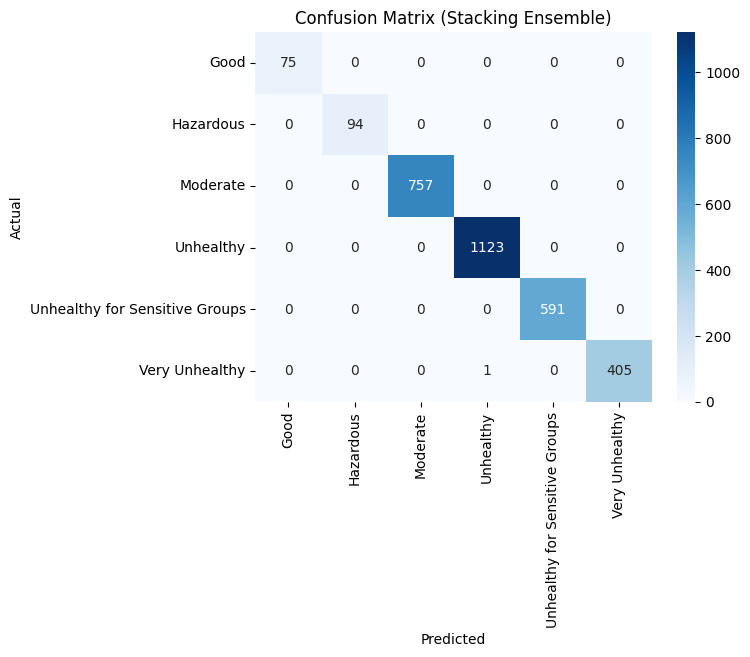

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred_stack)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Stacking Ensemble)')
plt.show()

Evaluation Metrics:

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("Stacking Ensemble Validation Results:")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_stack):.2f}")
print(classification_report(y_val, y_val_pred_stack, target_names=le.classes_))
print("Stacking Ensemble Test Results:")
print(classification_report(y_test, y_test_pred_stack, target_names=le.classes_))
print("XGBoost Validation Accuracy:", accuracy_score(y_val, y_val_pred_xgb))
print("Neural Network Validation Accuracy:", accuracy_score(y_val, y_val_pred_nn))

Stacking Ensemble Validation Results:
Accuracy: 1.00
                                precision    recall  f1-score   support

                          Good       1.00      1.00      1.00        75
                     Hazardous       1.00      1.00      1.00        94
                      Moderate       1.00      1.00      1.00       757
                     Unhealthy       1.00      1.00      1.00      1123
Unhealthy for Sensitive Groups       1.00      1.00      1.00       591
                Very Unhealthy       1.00      1.00      1.00       406

                      accuracy                           1.00      3046
                     macro avg       1.00      1.00      1.00      3046
                  weighted avg       1.00      1.00      1.00      3046

Stacking Ensemble Test Results:
                                precision    recall  f1-score   support

                          Good       1.00      1.00      1.00        74
                     Hazardous       1.00      

Neural Network Training History:

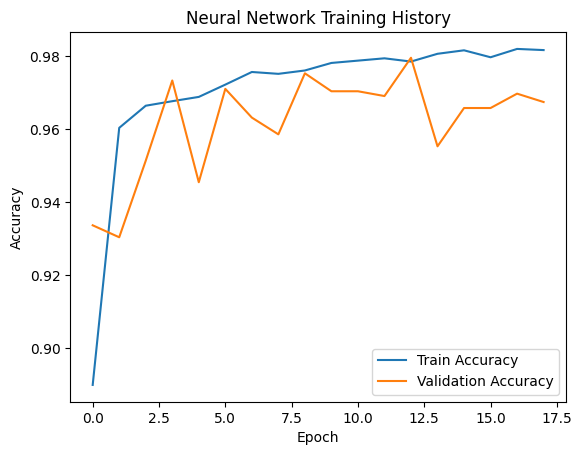

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Neural Network Training History')
plt.show()

Save Models and Results

In [ ]:
model.save('/content/air_quality_nn.keras')
import joblib
joblib.dump(best_xgb, '/content/air_quality_xgb.pkl')
joblib.dump(stacking_model, '/content/stacking_model.pkl')

['/content/stacking_model.pkl']

Save Predictions:

In [ ]:
test_results = pd.DataFrame({
    'Actual': le.inverse_transform(y_test),
    'Predicted_Stacking': le.inverse_transform(y_test_pred_stack),
    'Predicted_XGBoost': le.inverse_transform(y_test_pred_xgb),
    'Predicted_NN': le.inverse_transform(y_test_pred_nn)
})
test_results.to_csv('/content/test_predictions.csv', index=False)